In [121]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import math
import platform

pd.set_option('display.float_format',"{:.2f}".format)

# OS에 따라 다른 폰트 지정
if platform.system() == 'Darwin':   # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
elif platform.system() == 'Windows':  # Windows
    plt.rcParams['font.family'] = 'Malgun Gothic'
else:  # Linux (예: Colab, Ubuntu)
    plt.rcParams['font.family'] = 'NanumGothic'

In [122]:
df = pd.read_csv('./2025_Airbnb_NYC_listings.csv')
df.shape

(22308, 73)

### 데이터 확인

In [123]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 22308 entries, 0 to 22307
Data columns (total 73 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Unnamed: 0                                    22308 non-null  int64  
 1   id                                            22308 non-null  int64  
 2   source                                        22308 non-null  str    
 3   name                                          22308 non-null  str    
 4   description                                   21903 non-null  str    
 5   neighborhood_overview                         12262 non-null  str    
 6   host_id                                       22308 non-null  int64  
 7   host_name                                     22288 non-null  str    
 8   host_since                                    22288 non-null  str    
 9   host_location                                 17025 non-null  str    
 1

### 결측치 확인 및 처리
- 결측치가 어떤 컬럼에 있는가?
- 가짜 결측치는 없는가?
- 결측치를 가진 컬럼에서 결측치 비율은 어떻게 되는가?
- 각 결측치 drop 기준은 어떻게 정할까?
- 결측치를 drop할까? or 컬럼을 날릴까?

In [124]:
#가짜 결측치 리스트 만들기
fake_null = ['NaN', 'None', 'none', 'NULL', 'null', 'N/A', 'na', '']

In [125]:
#가짜 결측치 개수 확인
df.isin(fake_null).sum()

# ---- 결과는 없었음

Unnamed: 0                                      0
id                                              0
source                                          0
name                                            0
description                                     0
                                               ..
calculated_host_listings_count                  0
calculated_host_listings_count_entire_homes     0
calculated_host_listings_count_private_rooms    0
calculated_host_listings_count_shared_rooms     0
reviews_per_month                               0
Length: 73, dtype: int64

In [126]:
#가격이 중요하다! 가격 관련 컬럼들의 결측치 비율 확인         -----결측치 없음
(df[['price', 'minimum_nights','maximum_nights','availability_365','instant_bookable']].isna().sum() / len(df['price'])) * 100

price              0.00
minimum_nights     0.00
maximum_nights     0.00
availability_365   0.00
instant_bookable   0.00
dtype: float64

In [127]:
#모든 컬럼의 결측치 비율 확인 (정렬)
((df.isna().sum() / len(df)) * 100).sort_values(ascending=False)

calendar_updated                               100.00
license                                         79.99
neighbourhood                                   45.03
neighborhood_overview                           45.03
host_about                                      39.97
                                                ...  
instant_bookable                                 0.00
calculated_host_listings_count                   0.00
calculated_host_listings_count_entire_homes      0.00
calculated_host_listings_count_private_rooms     0.00
calculated_host_listings_count_shared_rooms      0.00
Length: 73, dtype: float64

In [128]:
#모든 컬럼들 중 결측치 비율이 너무 높거나, 낮은 컬럼 확인 
#                   -------- > 0% ~ 2% / 70% 이상 
#                                    결측치를 drop(2%이하?) | 컬럼을 delete(70%이상?) 할 컬럼 후보
missing_ratio = (df.isna().sum() / len(df)) * 100        

lower_mask = (missing_ratio > 0) & (missing_ratio <= 2)
higher_mask = missing_ratio >= 70

filtered = missing_ratio[lower_mask | higher_mask]
filtered.sort_values(ascending=False)

#70% 이상 결측치가 있는 컬럼 정보 : calender_updated, license >> 주요 컬럼표에 없음
#0%~2% 사이 컬럼 정보 : 호스트 관련 8개, 숙소 정보 5개 컬럼, 기타 컬럼 1개(has_availability : 예약 가능 여부)
#host_name, host_since, host_location, host_about, host_response_time, host_response_rate, host_acceptance_rate, host_is_superhost  

calendar_updated            100.00
license                      79.99
description                   1.82
host_is_superhost             1.68
has_availability              1.10
beds                          0.35
bedrooms                      0.22
host_name                     0.09
host_has_profile_pic          0.09
host_verifications            0.09
host_total_listings_count     0.09
host_listings_count           0.09
host_since                    0.09
host_identity_verified        0.09
bathrooms_text                0.06
bathrooms                     0.03
dtype: float64

### 컬럼 확인 
- 필요없는 컬럼은 어떤게 있을까?
- 데이터 타입으로 나누기 & 4가지 형태 중 어떤 형태일까?
- 가격과 상관 없는 컬럼 분류해보기

In [129]:
df.dtypes.value_counts()            #문자형이 30개, 숫자형 43개...

str        30
float64    23
int64      20
Name: count, dtype: int64

In [130]:
(df['price'].value_counts()/len(df['price'])) * 100         #종류가 너무 많아(연속형)

price
$150.00     1.69
$100.00     1.65
$120.00     1.30
$90.00      1.26
$200.00     1.24
            ... 
$852.00     0.00
$1,239.00   0.00
$872.00     0.00
$16.00      0.00
$14.00      0.00
Name: count, Length: 1022, dtype: float64

In [131]:
df['price'].value_counts()

price
$150.00      376
$100.00      368
$120.00      289
$90.00       280
$200.00      276
            ... 
$852.00        1
$1,239.00      1
$872.00        1
$16.00         1
$14.00         1
Name: count, Length: 1022, dtype: int64

In [132]:
df['price'].describe()      #뭔가 이상한디 . .? price 컬럼의 데이터타입..?

count       22308
unique       1022
top       $150.00
freq          376
Name: price, dtype: object

In [133]:
df['price'].info()      #가격이 object로 되어있음... 숫자형으로 바꿔야할듯

<class 'pandas.Series'>
RangeIndex: 22308 entries, 0 to 22307
Series name: price
Non-Null Count  Dtype
--------------  -----
22308 non-null  str  
dtypes: str(1)
memory usage: 174.4 KB


In [134]:
df['price'] = df['price'].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False).astype(float)
df['price'].info()      #price 컬럼의 dtype -> str에서 float으로 변환

<class 'pandas.Series'>
RangeIndex: 22308 entries, 0 to 22307
Series name: price
Non-Null Count  Dtype  
--------------  -----  
22308 non-null  float64
dtypes: float64(1)
memory usage: 174.4 KB


In [135]:
df['price'].describe()     #중앙값, 평균값에 비해 최대값이 너무 크다는 것을 알 수 있음. 이상치 존재 가능성

count   22308.00
mean      213.84
std       427.60
min         7.00
25%        85.00
50%       140.00
75%       240.00
max     20000.00
Name: price, dtype: float64

In [136]:
#agg 활용하기
df['price'].agg(['min', 'max', 'mean', 'median', 'std'])    #중앙값, 평균값에 비해 최대값이 너무 크다는 것을 알 수 있음. 이상치 존재 가능성

min          7.00
max      20000.00
mean       213.84
median     140.00
std        427.60
Name: price, dtype: float64

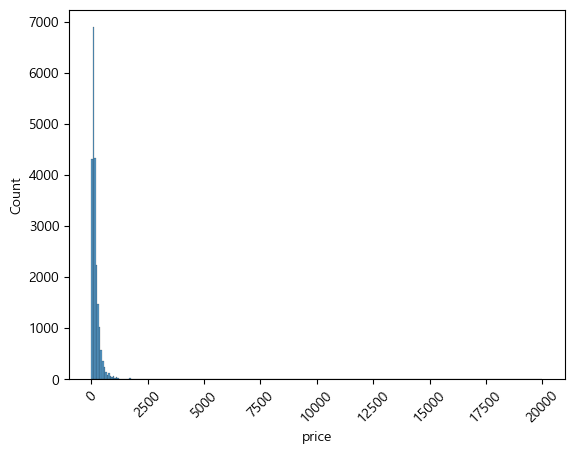

In [137]:
sns.histplot(df['price'])
plt.xticks(rotation=45)
plt.show()          #20000달러때문에 그래프가 너무 안이쁘다 . .

In [138]:
(len(df[df['price'] >= 1000])/ len(df['price'])) * 100  #가격이 1000달러 이상인 숙소는 전체의 1.5% 정도

1.4434283665052896

In [142]:
print("500달러 이상:", len(df[df["price"] >= 500]) / len(df['price']) * 100)        #가격이 500달러 이상인 숙소는 전체의 6% 정도
print("1000달러 이상:", len(df[df["price"] >= 1000]) / len(df['price']) * 100)      #가격이 1000달러 이상인 숙소는 전체의 1.5% 정도
print("2000달러 이상:", len(df[df["price"] >= 2000]) / len(df['price']) * 100)      #가격이 2000달러 이상인 숙소는 전체의 0.4% 정도
print("5000달러 이상:", len(df[df["price"] >= 5000]) / len(df['price']) * 100)      #가격이 5000달러 이상인 숙소는 전체의 0.09% 정도
print("10000달러 이상:", len(df[df["price"] >= 10000]) / len(df['price']) * 100)    #가격이 10000달러 이상인 숙소는 전체의 0.04% 정도
print("전체 숙소 수:", len(df['price']))

500달러 이상: 5.899228976152053
1000달러 이상: 1.4434283665052896
2000달러 이상: 0.38999462076385155
5000달러 이상: 0.08517123901739286
10000달러 이상: 0.04930966469428008
전체 숙소 수: 22308


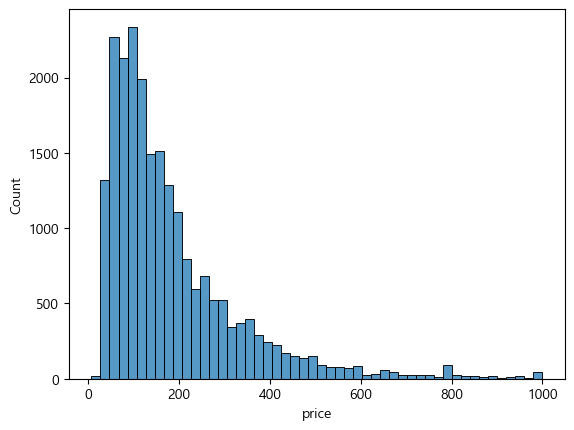

In [141]:
#일단 초고가 상품(가격이 1000달러 이상인 숙소는 전체의 1.5% 정도니까.. 얘네 빼고 보자)
sns.histplot(df[df['price'] <= 1000]['price'], bins=50)
plt.xticks(rotation=45)
plt.show()

### 범주형 변수 인코딩 (문자형 변수 -> 숫자형 변수로 바꿔주기)
- df.dtypes.value_counts()            #문자형이 30개, 숫자형 43개였다.
- 어떤게 범주형 변수일까?

In [145]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 22308 entries, 0 to 22307
Data columns (total 73 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Unnamed: 0                                    22308 non-null  int64  
 1   id                                            22308 non-null  int64  
 2   source                                        22308 non-null  str    
 3   name                                          22308 non-null  str    
 4   description                                   21903 non-null  str    
 5   neighborhood_overview                         12262 non-null  str    
 6   host_id                                       22308 non-null  int64  
 7   host_name                                     22288 non-null  str    
 8   host_since                                    22288 non-null  str    
 9   host_location                                 17025 non-null  str    
 1

In [147]:
df.select_dtypes(include='object').columns

C:\Users\lch\AppData\Local\Temp\ipykernel_11168\3732952691.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include='object').columns


Index(['source', 'name', 'description', 'neighborhood_overview', 'host_name',
       'host_since', 'host_location', 'host_about', 'host_response_time',
       'host_response_rate', 'host_acceptance_rate', 'host_is_superhost',
       'host_neighbourhood', 'host_verifications', 'host_has_profile_pic',
       'host_identity_verified', 'neighbourhood', 'neighbourhood_cleansed',
       'neighbourhood_group_cleansed', 'property_type', 'room_type',
       'bathrooms_text', 'amenities', 'has_availability',
       'calendar_last_scraped', 'first_review', 'last_review', 'license',
       'instant_bookable'],
      dtype='str')

In [150]:
for col in df.select_dtypes(include='object').columns:
    print(col, df[col].nunique())

source 1
name 21342
description 17854
neighborhood_overview 8232
host_name 5343
host_since 4567
host_location 421
host_about 5804
host_response_time 4
host_response_rate 65
host_acceptance_rate 96
host_is_superhost 2
host_neighbourhood 446
host_verifications 6
host_has_profile_pic 2
host_identity_verified 2
neighbourhood 1
neighbourhood_cleansed 221
neighbourhood_group_cleansed 5
property_type 57
room_type 4
bathrooms_text 31
amenities 18410
has_availability 1
calendar_last_scraped 2
first_review 3755
last_review 1694
license 1894
instant_bookable 2


C:\Users\lch\AppData\Local\Temp\ipykernel_11168\753239467.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:


In [152]:
str_cols = df.select_dtypes(include='object').columns
str_cols

C:\Users\lch\AppData\Local\Temp\ipykernel_11168\1282968590.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  str_cols = df.select_dtypes(include='object').columns


Index(['source', 'name', 'description', 'neighborhood_overview', 'host_name',
       'host_since', 'host_location', 'host_about', 'host_response_time',
       'host_response_rate', 'host_acceptance_rate', 'host_is_superhost',
       'host_neighbourhood', 'host_verifications', 'host_has_profile_pic',
       'host_identity_verified', 'neighbourhood', 'neighbourhood_cleansed',
       'neighbourhood_group_cleansed', 'property_type', 'room_type',
       'bathrooms_text', 'amenities', 'has_availability',
       'calendar_last_scraped', 'first_review', 'last_review', 'license',
       'instant_bookable'],
      dtype='str')

In [153]:
unique_counts = df[str_cols].nunique()
unique_counts

source                              1
name                            21342
description                     17854
neighborhood_overview            8232
host_name                        5343
host_since                       4567
host_location                     421
host_about                       5804
host_response_time                  4
host_response_rate                 65
host_acceptance_rate               96
host_is_superhost                   2
host_neighbourhood                446
host_verifications                  6
host_has_profile_pic                2
host_identity_verified              2
neighbourhood                       1
neighbourhood_cleansed            221
neighbourhood_group_cleansed        5
property_type                      57
room_type                           4
bathrooms_text                     31
amenities                       18410
has_availability                    1
calendar_last_scraped               2
first_review                     3755
last_review 

In [164]:
#unique 값이 2~4개인 컬럼 -----------> 사실상 얘네들만 인코딩 하면 되지않나?
low_cardinality = unique_counts[unique_counts.between(2,4)]
low_cardinality.sort_values(ascending=False)

host_response_time        4
room_type                 4
host_is_superhost         2
host_has_profile_pic      2
host_identity_verified    2
calendar_last_scraped     2
instant_bookable          2
dtype: int64

In [161]:
#unique 값이 7개 이상인 컬럼
high_cardinality = unique_counts[unique_counts >= 7]
high_cardinality.sort_values(ascending=False)

name                      21342
amenities                 18410
description               17854
neighborhood_overview      8232
host_about                 5804
host_name                  5343
host_since                 4567
first_review               3755
license                    1894
last_review                1694
host_neighbourhood          446
host_location               421
neighbourhood_cleansed      221
host_acceptance_rate         96
host_response_rate           65
property_type                57
bathrooms_text               31
dtype: int64

### 수치형 변수 스케일링 (정규화 | 표준화)

In [165]:
# 숫자형 컬럼만 뽑기
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
num_cols

Index(['Unnamed: 0', 'id', 'host_id', 'host_listings_count',
       'host_total_listings_count', 'latitude', 'longitude', 'accommodates',
       'bathrooms', 'bedrooms', 'beds', 'price', 'minimum_nights',
       'maximum_nights', 'minimum_minimum_nights', 'maximum_minimum_nights',
       'minimum_maximum_nights', 'maximum_maximum_nights',
       'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm', 'calendar_updated',
       'availability_30', 'availability_60', 'availability_90',
       'availability_365', 'number_of_reviews', 'number_of_reviews_ltm',
       'number_of_reviews_l30d', 'availability_eoy', 'number_of_reviews_ly',
       'estimated_occupancy_l365d', 'estimated_revenue_l365d',
       'review_scores_rating', 'review_scores_accuracy',
       'review_scores_cleanliness', 'review_scores_checkin',
       'review_scores_communication', 'review_scores_location',
       'review_scores_value', 'calculated_host_listings_count',
       'calculated_host_listings_count_entire_homes',
   